In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from data import data_loader
from features import tstat, volatility
from regime import state_labels

df = data_loader.get_data()
df = tstat.compute_tstat(df)
df = volatility.compute_volatility(df)
df = state_labels.label_volatility(df)
df = state_labels.label_regime(df)

[*********************100%***********************]  1 of 1 completed


In [4]:
df.head()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2015-01-05,167.508820,-0.018225,NaN,NaN,0,0
2015-01-06,165.931030,-0.009464,NaN,NaN,0,0
2015-01-07,167.998734,0.012384,NaN,NaN,0,0
2015-01-08,170.979935,0.017590,NaN,NaN,0,0
2015-01-09,169.609756,-0.008046,NaN,NaN,0,0


In [5]:
df.tail()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2024-12-24,594.320801,0.011054,1.432935,0.007806,0,1
2024-12-26,594.360352,0.000067,1.531650,0.007909,0,1
2024-12-27,588.103821,-0.010582,1.443919,0.007804,0,1
2024-12-30,581.392578,-0.011477,1.358181,0.007945,0,1
2024-12-31,579.277466,-0.003645,1.268189,0.008096,0,1


In [6]:
df[['Log Return', 'T-Stat_200', 'Volatility', 'Vol State', 'Regime']].tail(10)

Ticker,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,
2024-12-17,-0.004128,1.616927,0.006485,0,1
2024-12-18,-0.030257,1.587698,0.006517,0,1
2024-12-19,-0.000307,1.356806,0.007658,0,1
2024-12-20,0.011939,1.310547,0.007650,0,1
2024-12-23,0.005970,1.326529,0.007780,0,1
2024-12-24,0.011054,1.432935,0.007806,0,1
2024-12-26,0.000067,1.531650,0.007909,0,1
2024-12-27,-0.010582,1.443919,0.007804,0,1
2024-12-30,-0.011477,1.358181,0.007945,0,1


In [7]:
df[['Vol State', 'Regime']].dropna().dtypes

Ticker
Vol State    int64
Regime       int64
dtype: object

In [8]:
df['Log Return'].std()

0.011136943811922699

In [9]:
df['T-Stat_200'].describe()

count    2315.000000
mean        0.922884
std         0.926918
min        -1.310080
25%         0.207416
50%         0.924990
75%         1.697502
max         3.439011
Name: T-Stat_200, dtype: float64

In [10]:
df['Volatility'].describe()

count    2455.000000
mean        0.009738
std         0.005574
min         0.003136
25%         0.006557
50%         0.008349
75%         0.011527
max         0.038925
Name: Volatility, dtype: float64

In [11]:
df.isna().sum()

Ticker
SPY             0
Log Return      0
T-Stat_200    200
Volatility     60
Vol State       0
Regime          0
dtype: int64

In [12]:
df['Regime'].value_counts(normalize = True)

Regime
 0    0.557455
 1    0.434592
-1    0.007952
Name: proportion, dtype: float64

In [13]:
df['Vol State'].value_counts(normalize = True)

Vol State
0    0.769384
1    0.230616
Name: proportion, dtype: float64

<Axes: xlabel='Date', ylabel='T-Stat_200'>

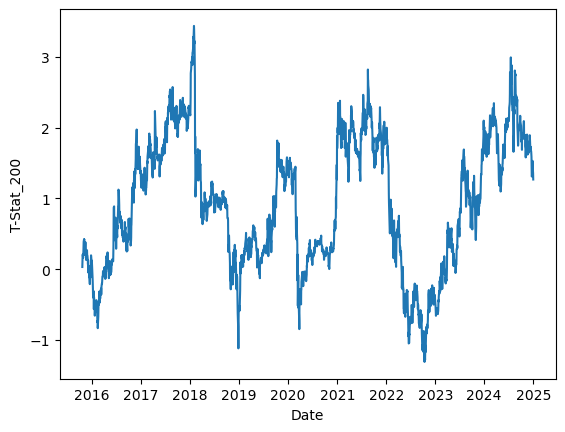

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data = df['T-Stat_200'])

<Axes: xlabel='Date', ylabel='Volatility'>

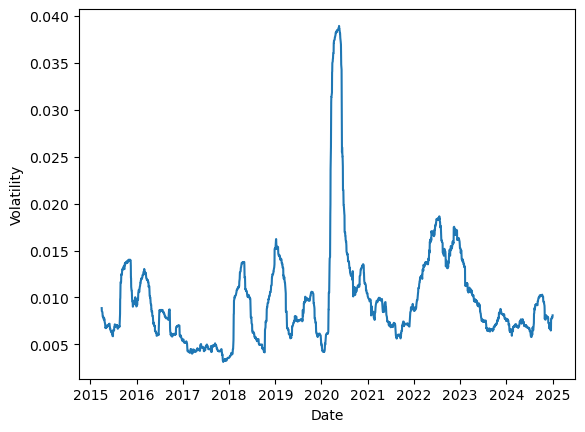

In [15]:
sns.lineplot(data = df['Volatility'])

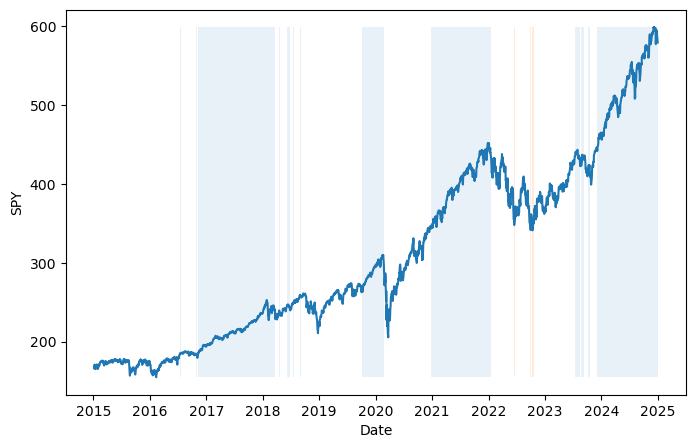

In [16]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.lineplot(data = df['SPY'], ax = ax)
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == 1), alpha = 0.1, label = 'Bull')
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == -1), alpha = 0.15, label = 'Bear')

In [17]:
df['Forward Return'] = df['Log Return'].shift(-1)
df_new = df.dropna(subset = ['Forward Return'])

bull_mean = df_new.loc[df['Regime'] == 1, 'Forward Return'].mean()
neutral_mean = df_new.loc[df['Regime'] == 0, 'Forward Return'].mean()
bear_mean = df_new.loc[df['Regime'] == -1, 'Forward Return'].mean()

print(bull_mean)
print(neutral_mean)
print(bear_mean)

df_new.loc[df_new['Regime'] == -1, 'Forward Return'].describe()

0.0006101974034271534
0.0003268204763549572
0.005810385094227226


count    20.000000
mean      0.005810
std       0.017141
min      -0.023053
25%      -0.006543
50%       0.002917
75%       0.024224
max       0.030516
Name: Forward Return, dtype: float64

In [18]:
df_new.groupby('Regime')['Forward Return'].std()

Regime
-1    0.017141
 0    0.013265
 1    0.007337
Name: Forward Return, dtype: float64

In [19]:
import numpy as np

bear_forward = df_new.loc[df_new['Regime'] == -1, 'Forward Return']

t = bear_forward.mean() / (bear_forward.std() / np.sqrt(len(bear_forward)))
print(t)

1.5159363960236252


In [20]:
bull_forward = df_new.loc[df_new['Regime'] == 1, 'Forward Return']

t = bull_forward.mean() / (bull_forward.std() / np.sqrt(len(bull_forward)))
print(t)

2.7484141504648845


In [21]:
neutral_forward = df_new.loc[df_new['Regime'] == 0, 'Forward Return']

t = neutral_forward.mean() / (neutral_forward.std() / np.sqrt(len(neutral_forward)))
print(t)

0.9224870068914225


In [22]:
df['Forward Vol'] = df['Volatility'].shift(-1)
df_new = df.dropna(subset =['Forward Vol'])

df_new.groupby('Vol State')['Forward Vol'].mean()

Vol State
0    0.007760
1    0.016131
Name: Forward Vol, dtype: float64

In [23]:
from regime import matrix

df = matrix.initialize_state(df)

transition_matrix = matrix.build_stationary_matrix(df)
print(transition_matrix)

Next State      -1_1       0_0       0_1       1_0       1_1
State                                                       
-1_1        0.800000  0.000000  0.200000  0.000000  0.000000
0_0         0.000000  0.968951  0.006424  0.024625  0.000000
0_1         0.008547  0.014957  0.970085  0.000000  0.006410
1_0         0.000000  0.021000  0.000000  0.975000  0.004000
1_1         0.000000  0.000000  0.043478  0.032609  0.923913


In [24]:
from regime import entropy

entropy_vector = entropy.find_entropy_vector(transition_matrix)
print(entropy_vector)

State
-1_1    0.500402
0_0     0.154200
0_1     0.165395
1_0     0.127899
1_1     0.321067
dtype: float64


<Axes: xlabel='Date', ylabel='Stationary Entropy'>

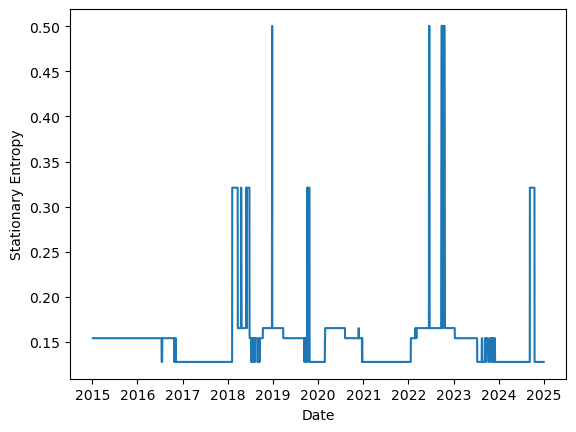

In [25]:
df = entropy.build_stationary_entropy(df, entropy_vector)

sns.lineplot(data = df['Stationary Entropy'])

new func


<Axes: xlabel='Date', ylabel='Expanding Entropy'>

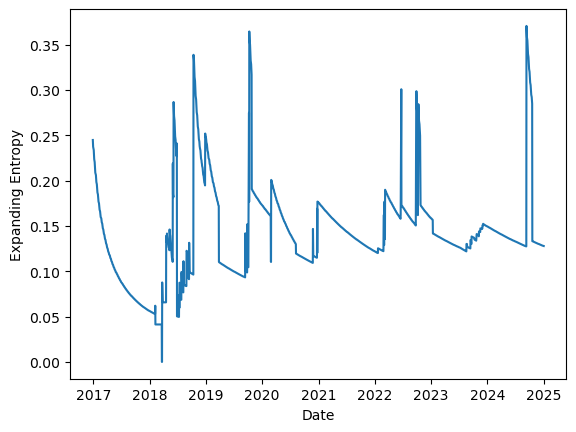

In [26]:
df = entropy.build_expanding_entropy(df)

sns.lineplot(data = df['Expanding Entropy'])

In [27]:
df['Expanding Entropy'].describe()

count    2015.000000
mean        0.141806
std         0.052179
min        -0.000000
25%         0.115453
50%         0.135928
75%         0.163542
max         0.370802
Name: Expanding Entropy, dtype: float64

In [28]:
df[[f'T-Stat_200', 'Log Return']].corr()

Ticker,T-Stat_200,Log Return
Ticker,,
T-Stat_200,1.000000,-0.016617
Log Return,-0.016617,1.000000


In [29]:
df[['Volatility', 'Log Return']].corr()

Ticker,Volatility,Log Return
Ticker,,
Volatility,1.000000,0.035205
Log Return,0.035205,1.000000


In [30]:
df[[f'T-Stat_200', 'Forward Return']].corr()

Ticker,T-Stat_200,Forward Return
Ticker,,
T-Stat_200,1.000000,-0.009882
Forward Return,-0.009882,1.000000


In [31]:
df[['Volatility', 'Forward Return']].corr()

Ticker,Volatility,Forward Return
Ticker,,
Volatility,1.000000,0.033796
Forward Return,0.033796,1.000000


In [32]:
from strategy import exposure

df = exposure.normalize_entropy(df)
df = exposure.normalize_tstat(df)
df = exposure.create_exposure(df)

In [33]:
df['Exposure'].describe()

count    2495.000000
mean        0.194498
std         0.371879
min        -0.813464
25%        -0.087075
50%         0.247994
75%         0.486695
max         0.916465
Name: Exposure, dtype: float64

In [47]:
(df['Exposure'].abs() > 0.8).mean()

0.025049701789264415

In [35]:
df['Trend'].describe()

count    2495.000000
mean        0.207692
std         0.398685
min        -0.874315
25%        -0.091426
50%         0.264245
75%         0.527570
max         0.952617
Name: Trend, dtype: float64

In [36]:
df['Confidence'].describe()

count    2515.000000
mean        0.936591
std         0.040957
min         0.793051
25%         0.913088
50%         0.928055
75%         0.963293
max         1.000000
Name: Confidence, dtype: float64

In [38]:
df['Exposure'].autocorr(lag = 1)

0.9383497576679901

In [40]:
df[['Exposure', 'Log Return']].corr()

Ticker,Exposure,Log Return
Ticker,,
Exposure,1.000000,-0.020452
Log Return,-0.020452,1.000000


In [41]:
df[['Exposure', 'Forward Return']].corr()

Ticker,Exposure,Forward Return
Ticker,,
Exposure,1.000000,-0.006125
Forward Return,-0.006125,1.000000


In [43]:
df.groupby('Vol State')['Exposure'].mean()

Vol State
0    0.23912
1    0.04717
Name: Exposure, dtype: float64

In [44]:
df.groupby('Regime')['Exposure'].mean()

Regime
-1   -0.407995
 0    0.109789
 1    0.312631
Name: Exposure, dtype: float64

In [45]:
df['Exposure Change'] = df['Exposure'].diff().abs()
df['Exposure Change'].mean()

0.09684354061108273

Text(0, 0.5, 'Exposure')

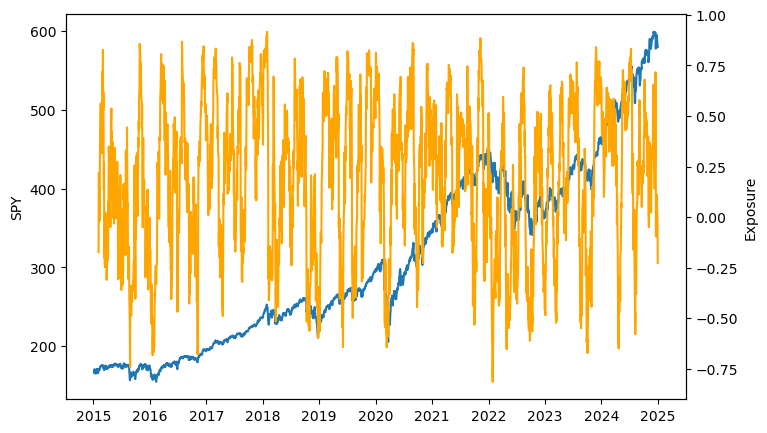

In [56]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['SPY'], label = 'SPY')
ax1.set_ylabel('SPY')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

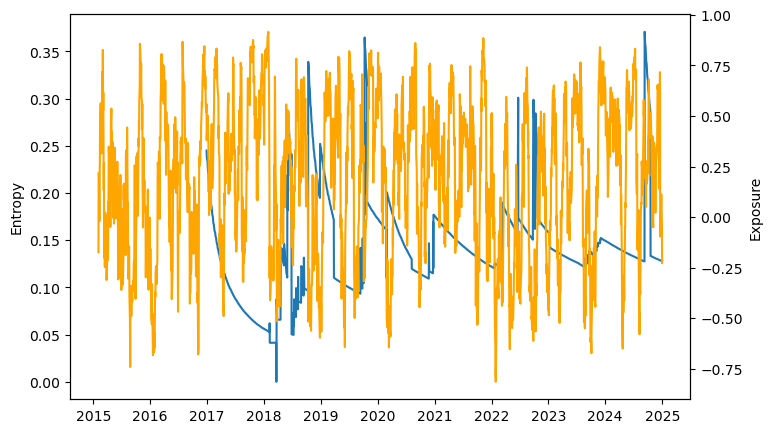

In [57]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Expanding Entropy'], label = 'Entropy')
ax1.set_ylabel('Entropy')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

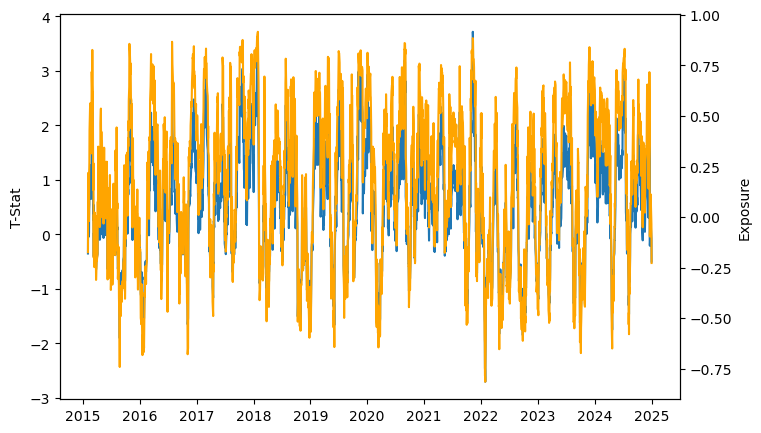

In [58]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['T-Stat_20'], label = 'T-Stat-20')
ax1.set_ylabel('T-Stat')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')